In [1]:
! pip install tensorflow_text

   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   -------- ------------------------------- 1.0/5.0 MB 12.5 MB/s eta 0:00:01
   -------- ------------------------------- 1.0/5.0 MB 12.5 MB/s eta 0:00:01
   ----------------------- ---------------- 2.9/5.0 MB 4.7 MB/s eta 0:00:01
   ------------------------- -------------- 3.1/5.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  5.0/5.0 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 4.7 MB/s  0:00:01
   ---------------------------------------- 0.0/455.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/455.9 MB 9.1 MB/s eta 0:00:50
   ---------------------------------------- 3.4/455.9 MB 8.4 MB/s eta 0:00:54
   ---------------------------------------- 5.0/455.9 MB 8.4 MB/s eta 0:00:54
    --------------------------------------- 6.8/455.9 MB 8.2 MB/s eta 0:00:55
    --------------------------------------- 8.7/455.9 MB 8.3 MB/s eta 0:00:55
    -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 2.10.0 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 3.19.6 which is incompatible.
tensorflow-intel 2.15.0 requires tensorboard<2.16,>=2.15, but you have tensorboard 2.10.1 which is incompatible.
tensorflow-intel 2.15.0 requires tensorflow-estimator<2.16,>=2.15.0, but you have tensorflow-estimator 2.10.0 which is incompatible.


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

In [3]:
! pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.3 MB 8.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 9.8 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.3 MB 9.3 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.3 MB 8.2 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.3 MB 7.3 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 6.2 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 5.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 5.1 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 3.9 MB/s eta 0:00:01
   ------------

In [6]:
import pandas as pd
df = pd.read_csv('spam.csv')
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [8]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
747/4825

0.15481865284974095

In [10]:
df_spam = df[df['Category']=='spam']
df_spam.shape

(747, 2)

In [11]:
df_ham = df[df['Category']=='ham']
df_ham.shape

(4825, 2)

In [12]:
df_ham_downsmapled = df_ham.sample(df_spam.shape[0])
df_ham_downsmapled.shape

(747, 2)

In [13]:
df_balanced = pd.concat([df_spam, df_ham_downsmapled])
df_balanced.shape

(1494, 2)

In [14]:
df_balanced['Category'].value_counts()

Category
spam    747
ham     747
Name: count, dtype: int64

In [15]:
df_balanced.sample(5)

,Category,Message
2400,ham,Oh... Kay... On sat right?
4430,ham,Hey they r not watching movie tonight so i'll ...
1637,ham,"No shit, but I wasn't that surprised, so I wen..."
738,spam,Hi. Customer Loyalty Offer:The NEW Nokia6650 M...
2565,ham,"Under the sea, there lays a rock. In the rock,..."


In [16]:
df_balanced['spam'] = df_balanced['Category'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(10)

,Category,Message,spam
2374,spam,XMAS Prize draws! We are trying to contact U. ...,1
1500,spam,"SMS. ac JSco: Energy is high, but u may not kn...",1
1449,spam,As a registered optin subscriber ur draw 4 £10...,1
615,ham,I called and said all to him:)then he have to ...,0
2736,ham,I meant middle left or right?,0
4587,spam,"Mila, age23, blonde, new in UK. I look sex wit...",1
2652,ham,"Text me when you get off, don't call, my phone...",0
2047,ham,"Aight fuck it, I'll get it later",0
2003,spam,TheMob>Yo yo yo-Here comes a new selection of ...,1
2038,ham,Oh sorry please its over,0


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['Message'], df_balanced['spam'], stratify=df_balanced['spam'])

In [18]:
X_train.head(5)

3227    Rose for red,red for blood,blood for heart,hea...
5550          Cool, what time you think you can get here?
1544    Hello from Orange. For 1 month's free access t...
2681    Solve d Case : A Man Was Found Murdered On  &l...
5115    Get 3 Lions England tone, reply lionm 4 mono o...
Name: Message, dtype: object

In [19]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [20]:
def get_sentence_embeding(sentences):
  preprocessed_text = bert_preprocess(sentences)
  return bert_encoder(preprocessed_text)['pooled_output']

get_sentence_embeding([
    "500$ discount. hurry up",
    "Bhavin, are you up for a volleyball game tomorrow?"
    ])

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.84351707, -0.5132726 , -0.8884572 , ..., -0.74748856,
        -0.75314724,  0.91964495],
       [-0.8205969 , -0.52094966, -0.9524536 , ..., -0.8804192 ,
        -0.7053686 ,  0.82520044]], dtype=float32)>

In [21]:
e = get_sentence_embeding([
    "banana",
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
])

In [22]:
e

<tf.Tensor: shape=(6, 768), dtype=float32, numpy=
array([[-0.7606918 , -0.14219396,  0.49604586, ...,  0.42165315,
        -0.5322141 ,  0.80312175],
       [-0.86023223, -0.21242936,  0.4915693 , ...,  0.3979806 ,
        -0.60506284,  0.8447163 ],
       [-0.71288604, -0.15463905,  0.38401675, ...,  0.3527874 ,
        -0.5099133 ,  0.73474073],
       [-0.82533467, -0.35550582, -0.590697  , ..., -0.01613692,
        -0.6141757 ,  0.872303  ],
       [-0.75041336, -0.2681263 , -0.26689765, ...,  0.02839323,
        -0.5938099 ,  0.7974989 ],
       [-0.7854437 , -0.2994969 ,  0.41027388, ...,  0.5222541 ,
        -0.49573544,  0.815075  ]], dtype=float32)>

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity([e[0]], [e[1]])

array([[0.9911088]], dtype=float32)

In [24]:
! pip install keras

In [26]:
from keras import activations

# bert layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# neural network layers
l = tf.keras.layers.Dropout(0.1, name='dropout')(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(l)

# construct final model
model = tf.keras.Model(inputs=[text_input], outputs=[l])


In [27]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_mask': (Non  0           ['text[0][0]']                   
                                e, 128),                                                          
                                 'input_word_ids':                                                
                                (None, 128),                                                      
                                 'input_type_ids':                                                
                                (None, 128)}                                                  

In [28]:
METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='prediction'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [30]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10


UnknownError: Graph execution error:

KeyError: '[70, 459, 222, 536, 702, 550, 707, 705, 1044, 604, 274, 248, 781, 1065, 554, 830, 133, 772, 743, 340, 1032, 22, 94, 1054, 440, 1012, 428] not in index'
Traceback (most recent call last):

  File "d:\AIML Internship\tf_env_py310\lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    return func(device, token, args)

  File "d:\AIML Internship\tf_env_py310\lib\site-packages\tensorflow\python\ops\script_ops.py", line 147, in __call__
    outputs = self._call(device, args)

  File "d:\AIML Internship\tf_env_py310\lib\site-packages\tensorflow\python\ops\script_ops.py", line 154, in _call
    ret = self._func(*args)

  File "d:\AIML Internship\tf_env_py310\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "d:\AIML Internship\tf_env_py310\lib\site-packages\keras\engine\data_adapter.py", line 513, in py_method
    return [slice_array(inp) for inp i

In [ ]:
model.evaluate(X_test, y_test)

12/12 [==============================] - 5s 310ms/step - loss: 0.2475 - accuracy: 0.9198 - prediction: 0.8985 - recall: 0.9465


[0.24753452837467194,
 0.9197860956192017,
 0.8984771370887756,
 0.9465240836143494]

In [ ]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

12/12 [==============================] - 4s 321ms/step


In [ ]:
import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
cm

array([[167,  20],
       [ 10, 177]])

Text(50.722222222222214, 0.5, 'Truth')

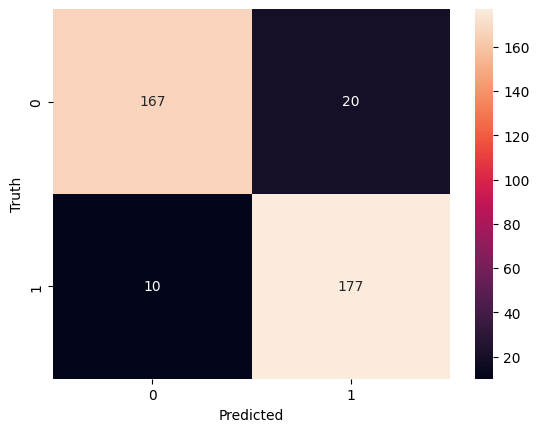

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92       187
           1       0.90      0.95      0.92       187

    accuracy                           0.92       374
   macro avg       0.92      0.92      0.92       374
weighted avg       0.92      0.92      0.92       374



### Inference

In [ ]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Cameral call 09061221061 from landline, Delivery withi 28 days. T Cs Box177. M221BP.  ',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricet game tomorrow',
    'Why don"t you wait "til at least wednesday to see if you get your.'
]

model.predict(reviews)

1/1 [==============================] - 1s 781ms/step


array([[0.8209324 ],
       [0.83908576],
       [0.8522406 ],
       [0.17980388],
       [0.12614277]], dtype=float32)